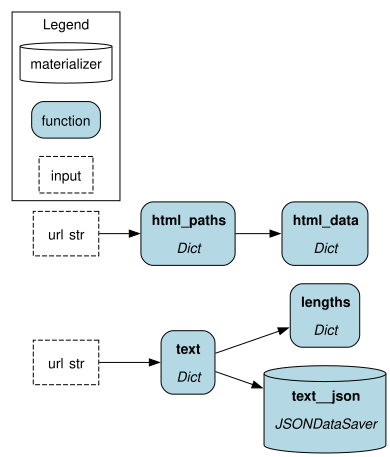

In [69]:
from hamilton.io.materialization import from_, to
import logging
from hamilton import driver,base
import bleak_house.download
import bleak_house.metrics

data_path = "data"
materializers = [
        to.json(
            id="text__json",  # name of the DataSaver node
            dependencies=["text"],
            path=f"{data_path}/bleak_house.json",
        ),
    ]

dr = (driver.Builder()
      .with_config({})
      .with_cache()
      .with_materializers(*materializers)
      .with_modules(bleak_house.download,
                    bleak_house.metrics).build()
      )
dr.display_all_functions()

In [70]:
results = dr.execute(["html_data"])

In [73]:
d = results['html_data']
d.keys()

dict_keys(['pg1023-images.html'])

In [37]:
tree = results['html_data']['pg1023-images.html']

In [42]:
import lxml.html


anchors = tree.xpath('//p[a[@id]]')

# Extract content between <p> containing <a> elements
for i, anchor in enumerate(anchors):
    anchor_id = anchor.xpath('.//a/@id')[0]  # Get the id of the <a>
    print(f"Anchor {i}: {anchor_id}")

    if i < len(anchors) - 1:
        next_anchor = anchors[i + 1]

        # Get all siblings between this <p> and the next <p> with an <a>
        content = anchor.xpath('./following-sibling::*[not(self::p[a[@id]])]')
        print("Content between this and the next <a>:")
        for item in content:
            if item == next_anchor:  # Stop at the next anchor
                break
            print(lxml.html.tostring(item, pretty_print=True).decode('utf-8'))
            break
    break


Anchor 0: cP
Content between this and the next <a>:
<p>&#160;</p>




In [59]:
from lxml import etree
from pathlib import Path


html_content = Path("data/pg1023-images.html").read_text()

# Parse the HTML content
tree = etree.HTML(html_content)

# Find all <a> elements with an id, embedded in <p>
anchors = tree.xpath('//p[a[@id]]')

# Extract titles and associated texts
result = []
for i, anchor in enumerate(anchors):
    title = ""
    text = ""

    # Get the title (assume it's the first <h3> or <h2> after the <a>)
    following_elements = anchor.xpath('./following-sibling::*')
    for element in following_elements:
        if element.tag in ['h3', 'h2']:
            title = ''.join(element.itertext()).strip()
        elif element.tag == 'p':
            text += '\n'.join(element.itertext()).strip() + '\n'

        # Stop when reaching the next <a> with an id
        if element.xpath('./a[@id]'):
            break

    if title or text:
        result.append({"id": anchors[i][0].attrib['id'],"title": title, "text": text.strip()})

# Print the results
for item in result:
    print(f"Id: {item['id']}")
    print(f"Title: {item['title']}")
    print(f"Length: {len(item['text'])}")
    print(f"Text: {item['text'][:90]}...")
    print("=" * 80)


Id: cP
Title: PREFACE
Length: 4268
Text: A Chancery judge once had the kindness to inform me, as one of a
company of some hundred a...
Id: F1
Title: 
Length: 0
Text: ...
Id: F2
Title: 
Length: 217
Text: **Another case, very clearly
described by a dentist, occurred at
the town of Columbus, in ...
Id: c1
Title: In Chancery
Length: 14957
Text: London. Michaelmas term lately over, and the Lord Chancellor sitting
in Lincoln’s Inn Hall...
Id: c2
Title: In Fashion
Length: 16253
Text: It is but a glimpse of the world of fashion that we want on this same
miry afternoon. It i...
Id: c3
Title: A Progress
Length: 41082
Text: I have a great deal of difficulty in beginning to write my portion of
these pages, for I k...
Id: c4
Title: Telescopic Philanthropy
Length: 26489
Text: We were to pass the night, Mr. Kenge told us when we arrived in his
room, at Mrs. Jellyby’...
Id: c5
Title: A Morning Adventure
Length: 30768
Text: Although the morning was raw, and although the fog still seemed
heavy—I say see